# Predicting secondary completion rates with poverty measures


---


Juliana Cobb, Suzanne Crabtree, Hannah Facci, Addison Orndorff


In [ ]:
# importing packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

## Data Importing and Cleaning

In [ ]:
# read in raw data
df = pd.read_csv('https://raw.githubusercontent.com/hbfacci/poverty_education/refs/heads/main/combined_50.csv')

df.head()

,Country Name,Country Code,Series Name,Series Code,1976 [YR1976],1977 [YR1977],1978 [YR1978],1979 [YR1979],1980 [YR1980],1981 [YR1981],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,"Educational attainment, at least completed upp...",SE.SEC.CUAT.UP.MA.ZS,..,..,..,..,..,..,...,..,19.1655944883765,..,..,18.5248093853414,12.1000003814697,19.8488998413086,..,..,..
1,Afghanistan,AFG,"Educational attainment, at least completed upp...",SE.SEC.CUAT.UP.ZS,..,..,..,..,..,..,...,..,11.7771822147423,..,..,11.8347043333891,9.46000003814697,12.5973300933838,..,..,..
2,Afghanistan,AFG,"Educational attainment, at least completed upp...",SE.SEC.CUAT.UP.FE.ZS,..,..,..,..,..,..,...,..,4.24002751251591,..,..,4.97310527668358,5.19999980926514,5.70547008514404,..,..,..
3,Afghanistan,AFG,Poverty headcount ratio at $8.30 a day (2021 P...,SI.POV.UMIC,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,Afghanistan,AFG,Poverty headcount ratio at national poverty li...,SI.POV.NAHC,..,..,..,..,..,..,...,54.5,..,..,47.1,..,..,..,..,..,..


In [ ]:
# the data needs to be organized before it can be cleaned. use multiindices
# sort the values by country first, then series
df.sort_values(['Country Name', 'Series Name'], inplace=True)

# add a simpler, searchable series column
df['Series'] = df['Series Name'].map({
    'Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)': 'ed_attain_fem',
    'Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)': 'ed_attain_male',
    'Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative)': 'ed_attain_total',
    'Poverty headcount ratio at $8.30 a day (2021 PPP) (% of population)': 'poverty_ratio_wage',
    'Poverty headcount ratio at national poverty lines (% of population)': 'poverty_ratio_nat',
    'GDP per capita (constant 2015 US$)': 'GDP_const',
    'GDP per capita growth (annual %)': 'GDP_growth'

})

# drop empty buffer rows
df.dropna(subset=['Series'], inplace=True)

# set indices
df.set_index(['Country Name', 'Series'], inplace=True)

# remove extraneous columns, simplify column names, rearrange stuff
col = df.pop('Series Name')
df.insert(len(df.columns), 'Series Name', col)
df.drop(columns = ['Series Code', 'Country Code'], inplace=True)
df.columns = [col[:4] for col in df.columns]
df.rename(columns = {'Seri': 'Series Description'}, inplace=True)
df.replace('..', np.nan, inplace=True)
# filter to range 2002-2022
df.drop(columns = [str(year) for year in range(1976, 2002)], inplace=True)
df.drop(columns = [str(year) for year in range(2023, 2026)], inplace=True)

In [ ]:
# actual data cleaning

# sort by number of NaN per country name index
nan_counts = df.isnull().sum(axis=1).groupby(level=['Country Name']).sum()
df = df.loc[nan_counts.sort_values(ascending=False).index]
nan_counts = nan_counts.sort_values(ascending=False)
nan_counts

,0
Country Name,
British Virgin Islands,147
Not classified,147
Gibraltar,147
"Korea, Dem. People's Rep.",147
St. Martin (French part),140
...,...
Greece,1
Paraguay,1
Indonesia,0


In [ ]:
# display data
df.loc['Gibraltar']

,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Series Description
Series,,,,,,,,,,,,,,,,,,,,,
ed_attain_fem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Educational attainment, at least completed upp..."
ed_attain_male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Educational attainment, at least completed upp..."
ed_attain_total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Educational attainment, at least completed upp..."
GDP_const,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GDP per capita (constant 2015 US$)
GDP_growth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GDP per capita growth (annual %)
poverty_ratio_wage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Poverty headcount ratio at $8.30 a day (2021 P...
poverty_ratio_nat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Poverty headcount ratio at national poverty li...


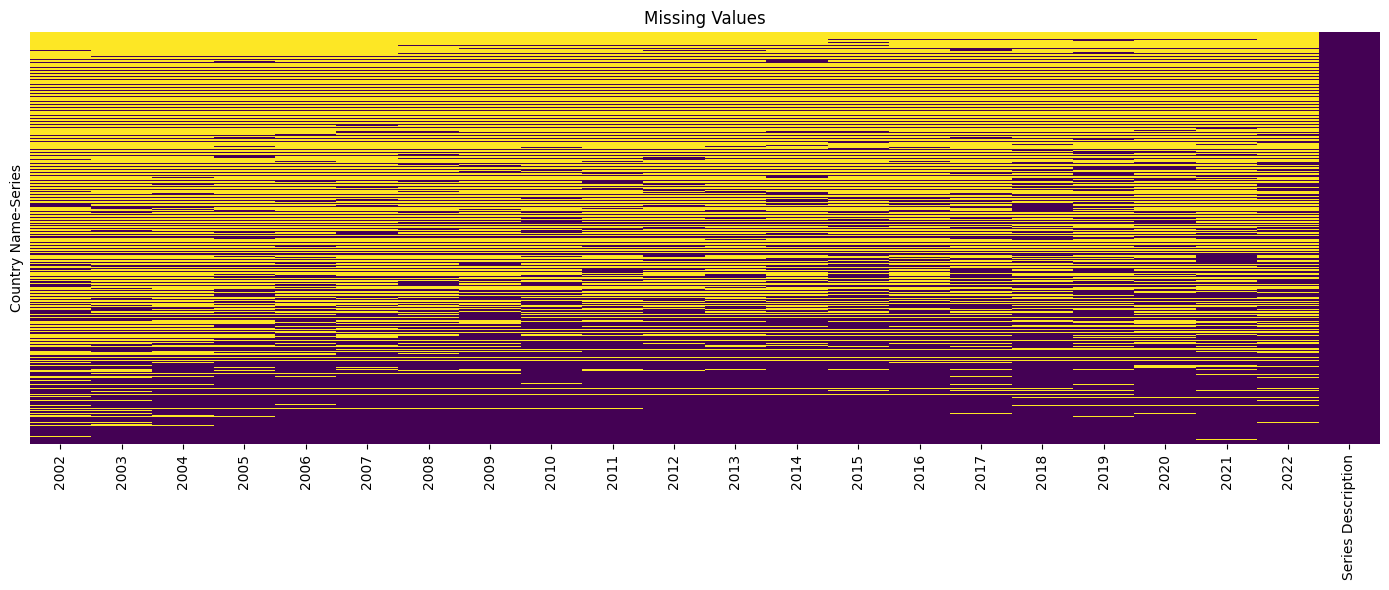

In [ ]:
# plot data to see how much we have
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values')
plt.tight_layout()
plt.show()

In [ ]:
# Filter to only three series of interest
df_three_series = df[df.index.get_level_values('Series').isin(['ed_attain_total', 'poverty_ratio_wage', 'GDP_const'])]

# Count NaNs per country
nan_counts = df_three_series.isnull().sum(axis=1)
nan_counts = nan_counts.groupby(level='Country Name').sum()
nan_counts = nan_counts.sort_values(ascending=False)
nan_counts

,0
Country Name,
St. Martin (French part),63
British Virgin Islands,63
Not classified,63
Gibraltar,63
"Korea, Dem. People's Rep.",63
...,...
Moldova,0
Slovenia,0
Peru,0


In [ ]:
# 2) drops countries with less than 50% values across all 7 series
# now that we have identifies criteria for missing data, we can filter out the
# countries and principalities that we can't use
#keep_countries = nan_counts[nan_counts < 74].index
#df_clean = df.loc[keep_countries]
#kept = df_clean.index.get_level_values('Country Name').unique()
#kept

# 2) drops countries with less than 40% values across 3 series
# Calculate total possible values per country (3 series × years)
# year_columns = [col for col in df.columns if col.isdigit()]
# total_per_country = 3 * len(year_columns)

# # Keep countries with less than 40% missing across all three series
# keep_countries = nan_counts[nan_counts < (0.6 * total_per_country)].index

# # Filter the original dataframe
# df_clean = df[df.index.get_level_values('Country Name').isin(keep_countries)]

# kept = df_clean.index.get_level_values('Country Name').unique()
# print(f"Kept {len(kept)} countries")
# print(kept)

In [ ]:
# 3) dropscountries with less than 40% values for any of 3 series individually
# Calculate percentage missing per country per series
year_columns = [col for col in df.columns if col.isdigit()]
num_years = len(year_columns)

# Get NaN counts per country per series
nan_by_series = df_three_series.isnull().sum(axis=1)
nan_by_country_series = nan_by_series.groupby(level=['Country Name', 'Series']).sum()

# Calculate percentage missing
pct_missing = (nan_by_country_series / num_years) * 100

# Keep countries where all three series have < 60% missing
keep_countries = pct_missing.groupby(level='Country Name').apply(lambda x: (x < 60).all())
keep_countries = keep_countries[keep_countries].index

df_clean = df[df.index.get_level_values('Country Name').isin(keep_countries)]

kept = df_clean.index.get_level_values('Country Name').unique()
print(f"Kept {len(kept)} countries")
print(kept)

Kept 63 countries
Index(['Iran, Islamic Rep.', 'United Kingdom', 'Mongolia', 'Viet Nam',
       'Israel', 'Montenegro', 'Armenia', 'Albania', 'Korea, Rep.', 'Chile',
       'Luxembourg', 'Georgia', 'Honduras', 'Uruguay', 'Mexico', 'Thailand',
       'Canada', 'Russian Federation', 'Serbia', 'Malta', 'Ireland', 'Denmark',
       'Bolivia', 'Brazil', 'North Macedonia', 'United States', 'Germany',
       'Slovak Republic', 'Poland', 'France', 'El Salvador', 'Moldova',
       'Hungary', 'Belgium', 'Netherlands', 'Bulgaria', 'Croatia', 'Iceland',
       'Dominican Republic', 'Colombia', 'Czechia', 'Sweden', 'Norway',
       'Latvia', 'Ecuador', 'Estonia', 'Panama', 'Switzerland', 'Cyprus',
       'Romania', 'Turkiye', 'Portugal', 'Lithuania', 'Austria', 'Italy',
       'Slovenia', 'Spain', 'Finland', 'Greece', 'Paraguay', 'Indonesia',
       'Costa Rica', 'Peru'],
      dtype='object', name='Country Name')


In [ ]:
# world map for funsies
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip")
coords = world[['NAME', 'geometry']].copy()
# reprojecting per geopandas warning
coords['coordinates'] = coords['geometry'].to_crs(epsg=3857).centroid.to_crs(epsg=4326)
coords['coordinates'] = coords['geometry'].centroid
coords = coords.rename(columns={'NAME': 'Country Name'})

# check to see if there are naming mismatches between gpd and our list
set(kept) - set(world['ADMIN'])


# manual fixes on kept

name_fix_kept = {
  'Egypt, Arab Rep.' : 'Egypt',
  'Hong Kong SAR, China' : 'Hong Kong S.A.R.',
  'Iran, Islamic Rep.' : 'Iran',
  'Korea, Rep.' : 'South Korea',
  'Kyrgyz Republic' : 'Kyrgyzstan',
  'Russian Federation' : 'Russia',
  'Serbia' : 'Republic of Serbia',
  'Slovak Republic' : 'Slovakia',
  'Tanzania' : 'United Republic of Tanzania',
  'Turkiye' : 'Turkey',
  'United States' : 'United States of America',
  'Venezuela, RB' : 'Venezuela',
  'Viet Nam' : 'Vietnam',
  'West Bank and Gaza' : 'Palestine'
}
kept_fixed = [name_fix_kept.get(c, c) for c in kept]

set(kept_fixed) - set(world['ADMIN'])

df_clean.index = df_clean.index.set_levels(
    df_clean.index.levels[0].map(lambda x: name_fix_kept.get(x, x)),
    level='Country Name'
)

# define a numeric version for querying and plotting
df_clean_numeric = df_clean.apply(pd.to_numeric, errors='coerce')

# indexed numeric version
clean_data_index = df_clean_numeric.sort_index(level=['Country Name', 'Series'])

/tmp/ipykernel_9244/3650780637.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords['coordinates'] = coords['geometry'].centroid


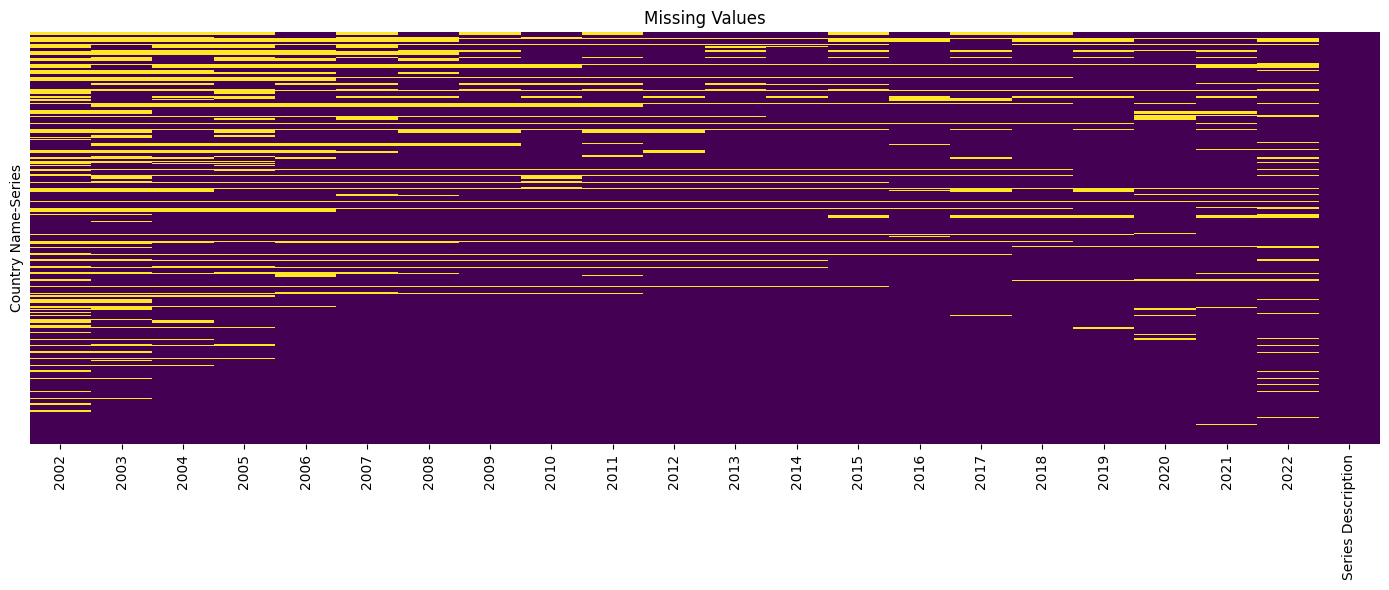

In [ ]:
# new visualization
plt.figure(figsize=(14, 6))
sns.heatmap(df_clean.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values')
plt.tight_layout()
plt.show()

In [ ]:
dropped = df.index.get_level_values('Country Name').unique().difference(kept)
dropped

Index(['Afghanistan', 'Africa Eastern and Southern',
       'Africa Western and Central', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Arab World', 'Argentina',
       ...
       'Upper middle income', 'Uzbekistan', 'Vanuatu', 'Venezuela, RB',
       'Virgin Islands (U.S.)', 'West Bank and Gaza', 'World', 'Yemen, Rep.',
       'Zambia', 'Zimbabwe'],
      dtype='object', name='Country Name', length=203)

In [ ]:
# get year where we have the least/most data
df_clean_numeric.isnull().sum().sort_values(ascending= True)

,0
2014,26
2016,27
2019,29
2018,29
2020,30
2012,31
2013,33
2021,35
2015,36
2017,38


## Data Visualization

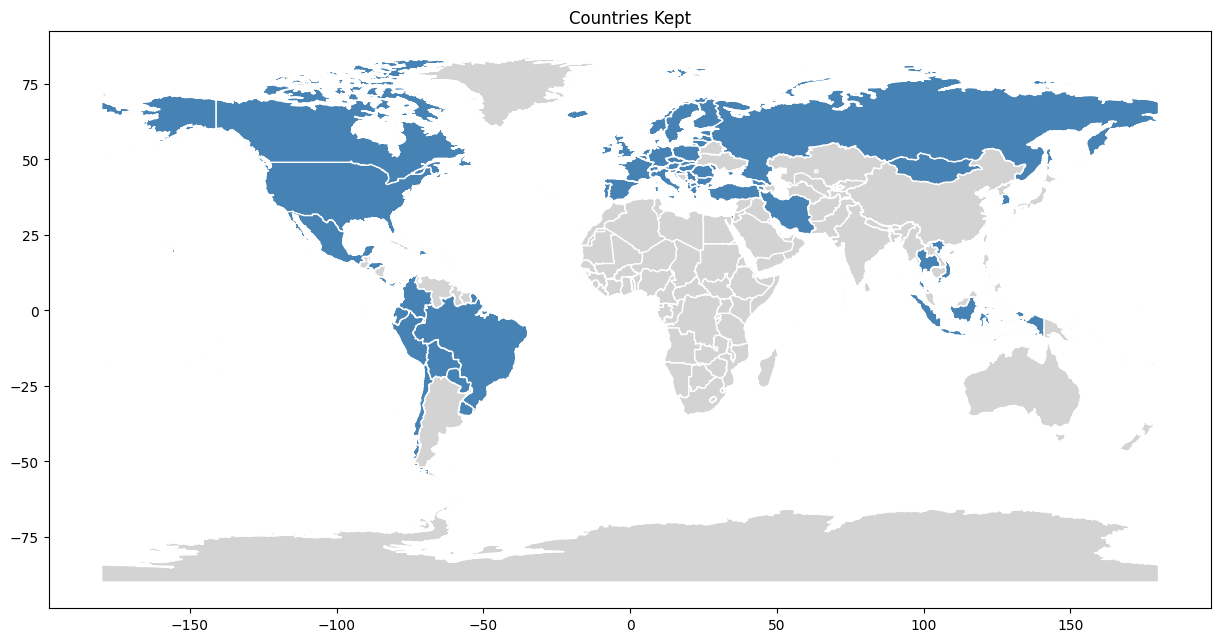

In [ ]:
# plotting the map
fig, ax = plt.subplots(figsize=(15, 10))

# plot all countries as base layer
world.plot(ax=ax, color='lightgrey', edgecolor='white')

# highlight countries
world[world['ADMIN'].isin(kept_fixed)].plot(ax=ax, color='steelblue', edgecolor='white')

plt.title('Countries Kept')
plt.show()

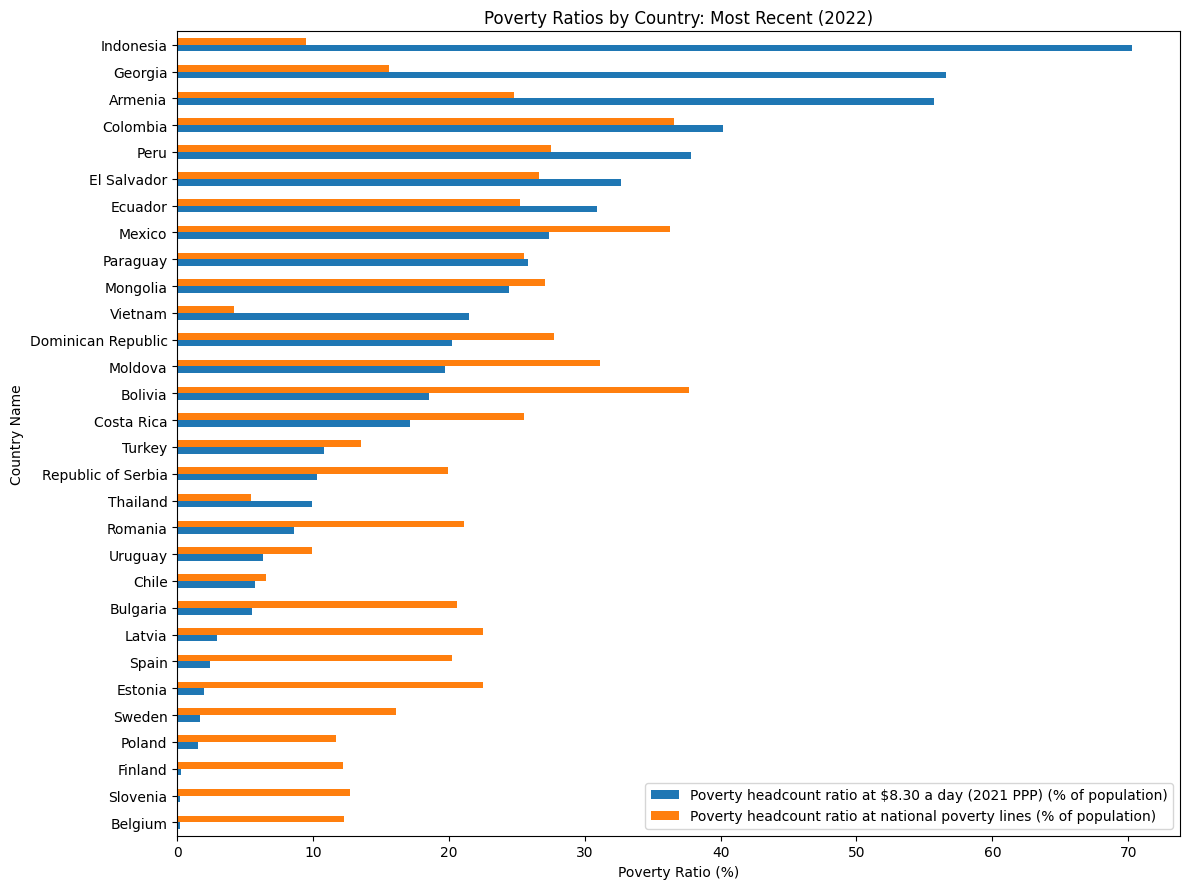

In [ ]:
# kept countries by poverty line and poverty @ $8.30
data1 = df_clean_numeric.xs('poverty_ratio_wage', level='Series')['2022'].dropna().sort_values()
data2 = df_clean_numeric.xs('poverty_ratio_nat', level='Series')['2022'].dropna().sort_values()

descriptions = {
    'poverty_ratio_wage': df_clean.xs('poverty_ratio_wage', level='Series')['Series Description'].iloc[0],
    'poverty_ratio_nat': df_clean.xs('poverty_ratio_nat', level='Series')['Series Description'].iloc[0]
}

combined1 = pd.DataFrame({'poverty_ratio_wage': data1, 'poverty_ratio_nat': data2}).dropna().sort_values('poverty_ratio_wage')
combined1 = combined1.rename(columns=descriptions)

fig, ax = plt.subplots(figsize=(12, len(combined1) * 0.3))
combined1.plot(kind='barh', ax=ax)
plt.title('Poverty Ratios by Country: Most Recent (2022)')
plt.xlabel('Poverty Ratio (%)')
plt.tight_layout()
plt.show()

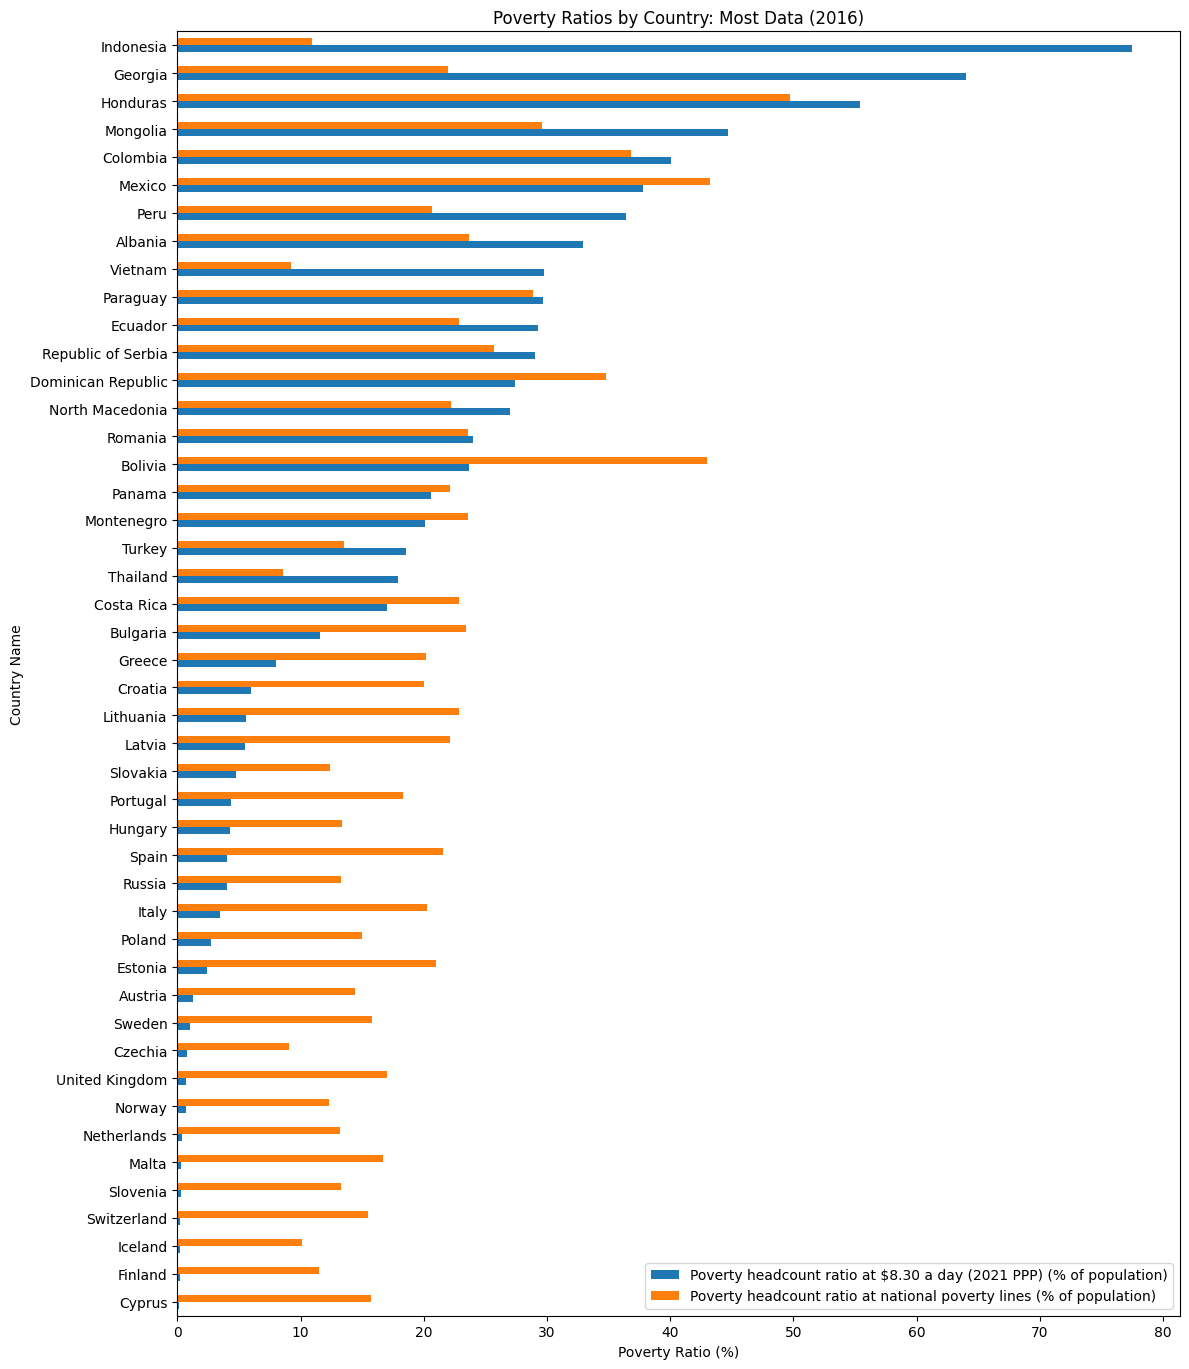

In [ ]:
data3 = df_clean_numeric.xs('poverty_ratio_wage', level='Series')['2016'].dropna().sort_values()
data4 = df_clean_numeric.xs('poverty_ratio_nat', level='Series')['2016'].dropna().sort_values()

combined2 = pd.DataFrame({'poverty_ratio_wage': data3, 'poverty_ratio_nat': data4}).dropna().sort_values('poverty_ratio_wage')
combined2 = combined2.rename(columns=descriptions)

fig, ax = plt.subplots(figsize=(12, len(combined2) * 0.3))
combined2.plot(kind='barh', ax=ax)
plt.title('Poverty Ratios by Country: Most Data (2016)')
plt.xlabel('Poverty Ratio (%)')
plt.tight_layout()
plt.show()

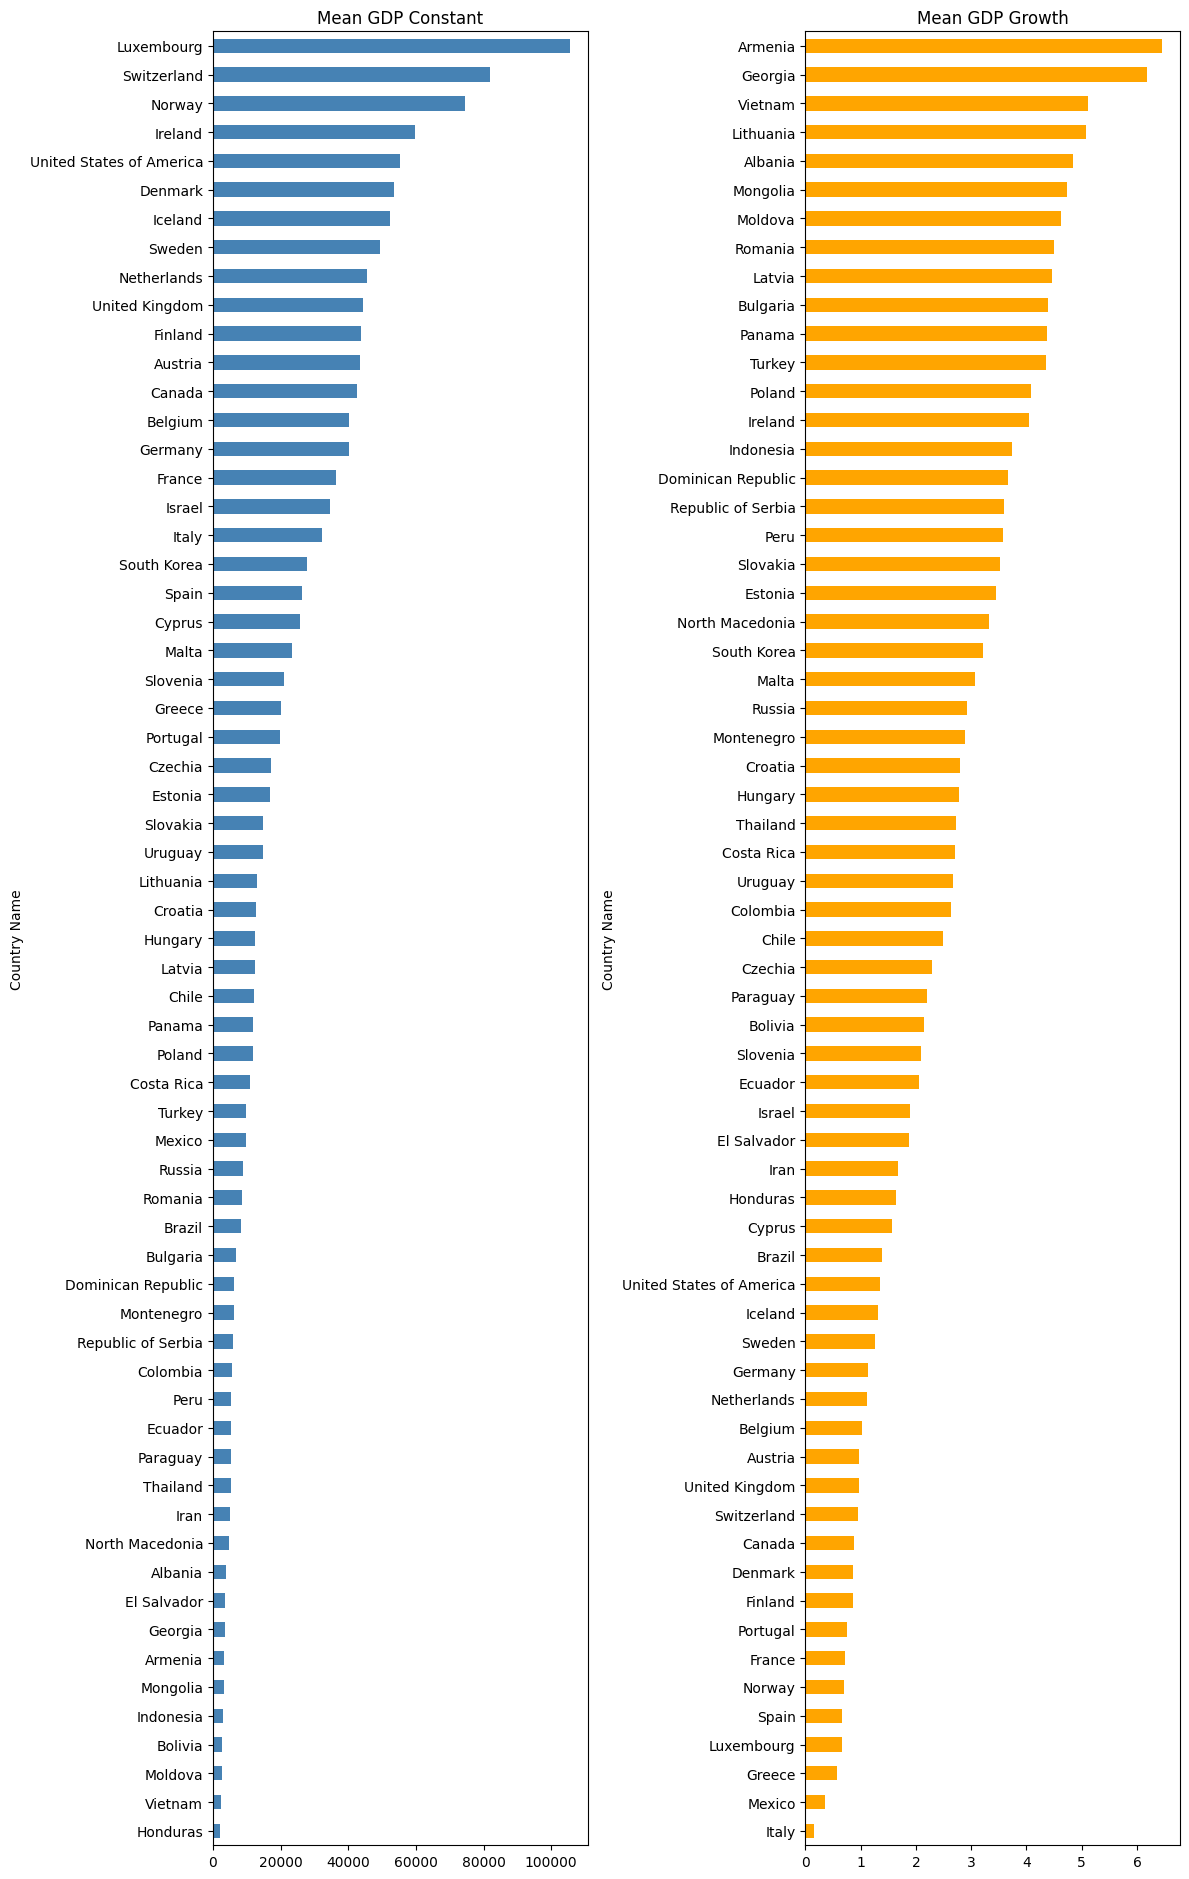

In [ ]:
# averaging the existing gdp data by country
# get sub df with only gdp data
GDP_const_df = clean_data_index.xs('GDP_const', level='Series').drop(columns='Series Description')
GDP_growth_df = clean_data_index.xs('GDP_growth', level='Series').drop(columns='Series Description')


# average the data over the years
GDP_const_df = GDP_const_df.groupby('Country Name').mean().mean(axis = 1)
GDP_growth_df = GDP_growth_df.groupby('Country Name').mean().mean(axis = 1)

# side by side plot of the two gdp averages
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, len(GDP_const_df) * 0.3))
GDP_const_df.sort_values().plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Mean GDP Constant')

GDP_growth_df.sort_values().plot(kind='barh', ax=ax2, color='orange')
ax2.set_title('Mean GDP Growth')

plt.tight_layout()
plt.show()

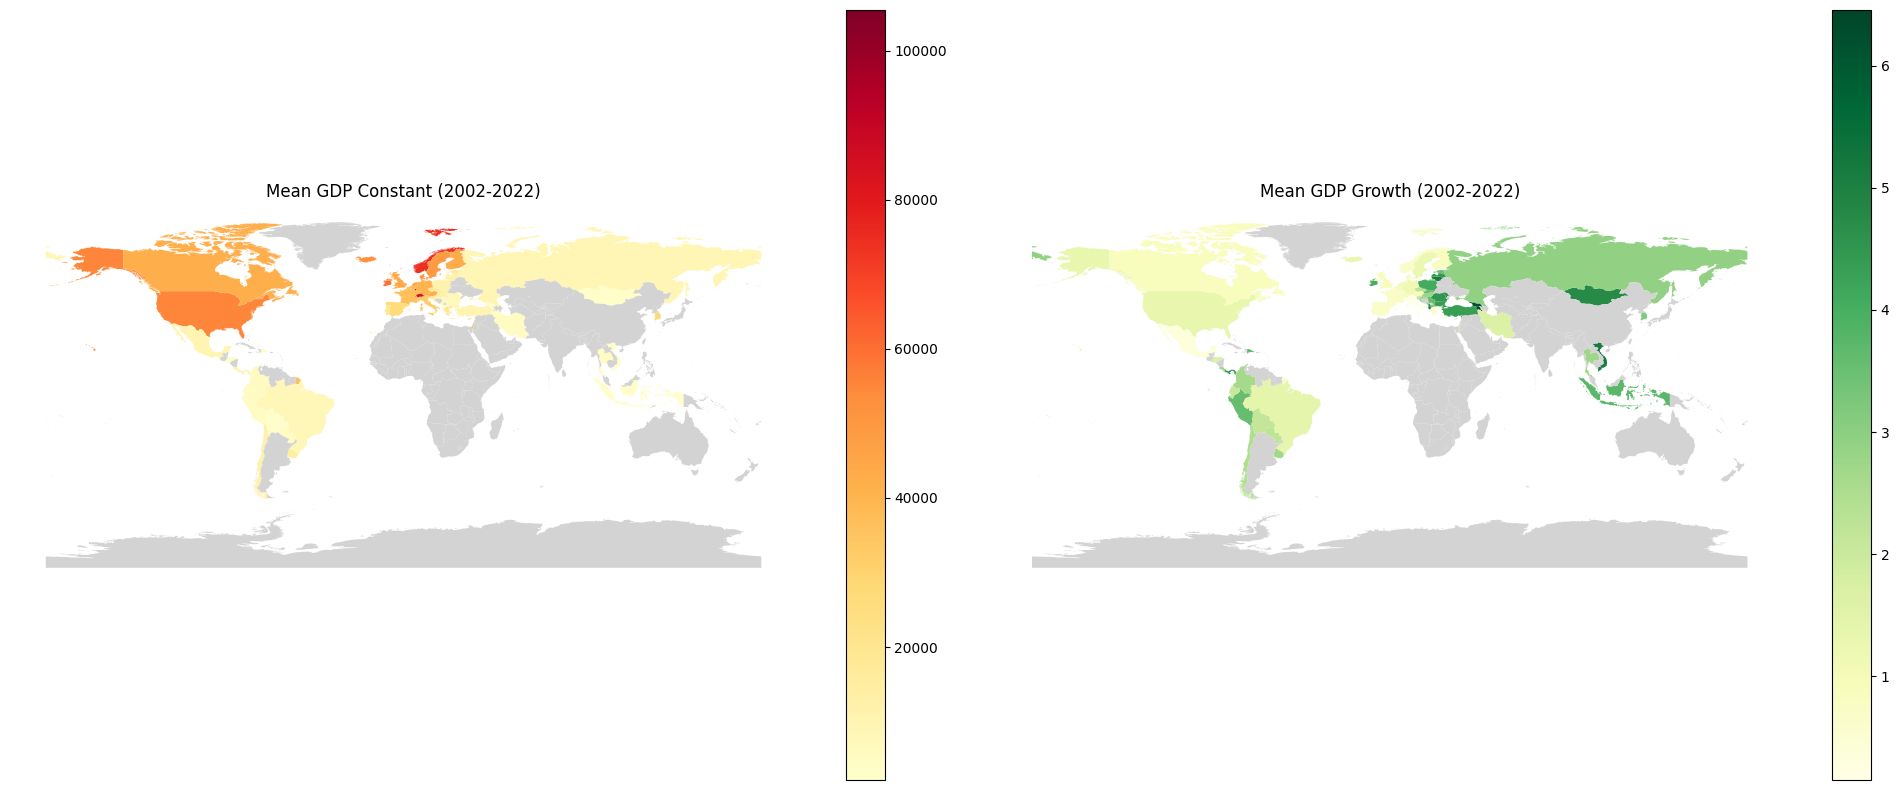

In [ ]:
# chloropleth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

for ax, data, col, title, cmap in [
    (ax1, GDP_const_df.to_frame('GDP Constant'), 'GDP Constant', 'Mean GDP Constant (2002-2022)', 'YlOrRd'),
    (ax2, GDP_growth_df.to_frame('GDP Growth'), 'GDP Growth', 'Mean GDP Growth (2002-2022)', 'YlGn')
]:
    world_plot = world.merge(data, left_on='ADMIN', right_index=True, how='left')
    world_plot.plot(column=col, ax=ax, legend=True, cmap=cmap, missing_kwds={'color': 'lightgrey'})
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

##Imputation

In [ ]:
# linear interpolation
data_imput = clean_data_index.interpolate(axis=1, method='linear')

# fill tails
data_imput = data_imput.ffill(axis=1).bfill(axis=1)

# make new data frame where NaN is replaced
data_filled = clean_data_index.copy()
data_filled = data_filled.where(data_filled.notna(), data_imput)

In [ ]:
# find a country/series with NaNs
clean_data_index.isnull().sum(axis=1).sort_values(ascending=False).head(20)

,,0
Country Name,Series,
Brazil,poverty_ratio_nat,22
Israel,poverty_ratio_nat,22
South Korea,poverty_ratio_nat,22
United States of America,poverty_ratio_nat,22
Iran,poverty_ratio_nat,22
Canada,poverty_ratio_nat,22
Luxembourg,poverty_ratio_nat,20
Uruguay,poverty_ratio_nat,20
France,poverty_ratio_nat,20


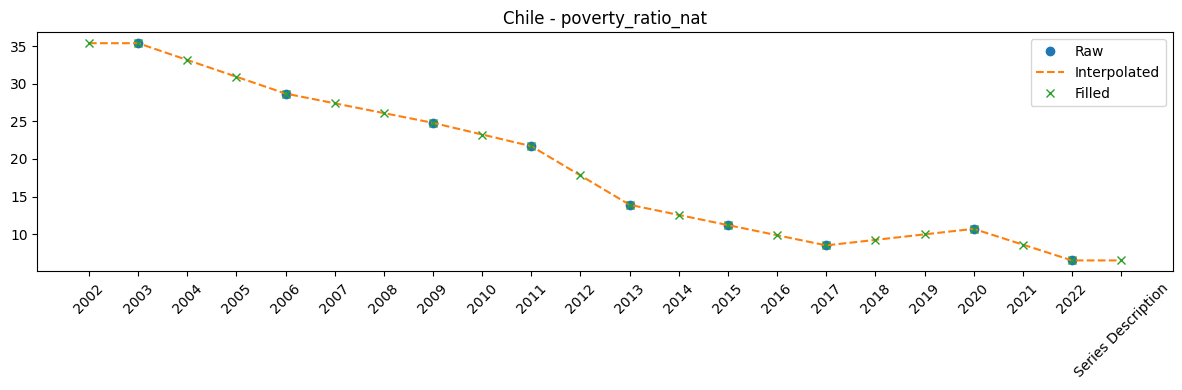

In [ ]:
# test viz
country = 'Chile'
series = 'poverty_ratio_nat'


raw = clean_data_index.xs((country, series), level=('Country Name', 'Series')).squeeze()
interp = data_imput.xs((country, series), level=('Country Name', 'Series')).squeeze()
filled = data_filled.xs((country, series), level=('Country Name', 'Series')).squeeze()

x = [str(c) for c in raw.index]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x, raw.values, label='Raw', linestyle='none', marker='o')
ax.plot(x, interp.values, label='Interpolated', linestyle='--')
ax.plot(x, filled.values, label='Filled', linestyle='none', marker='x')
plt.xticks(rotation=45)
plt.title(f'{country} - {series}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# saving dataframes as csv
df_clean.to_csv('clean_20_years.csv')
df_clean_numeric.to_csv('clean_20_years_numeric.csv')

## More Exploratory Data Analysis

In [ ]:
# import ordinary least squares
import statsmodels.formula.api as smf

In [ ]:
# transform data to workable format
df_temp = data_filled.reset_index()
df_temp = df_temp.drop(columns=['Series Description'])
df_melted = df_temp.melt(
    id_vars=['Country Name', 'Series'],
    var_name='Year',
    value_name='Value'
)

# convert year to integer
df_melted['Year'] = df_melted['Year'].astype(int)

# pivot rows to columns
df_wide = df_melted.pivot_table(
    index=['Country Name', 'Year'],
    columns='Series',
    values='Value'
).reset_index()

# flatten and rename columns
df_wide.columns.name = None
df_wide = df_wide.rename(columns={
    'Country Name': 'Country',
    'ed_attain_total': 'Educational_Attainment_Total',
    'ed_attain_fem': 'Educational_Attainment_Female',
    'ed_attain_male': 'Educational_Attainment_Male',
    'GDP_const': 'GDP_Constant',
    'poverty_ratio_nat': 'Poverty_Ratio_National',
    'poverty_ratio_wage': 'Poverty_Ratio_Wage'
})

# add log of GDP Constant as a new column, best practice when using gdp as variable
df_wide['log_GDP_Constant'] = np.log(df_wide['GDP_Constant'])


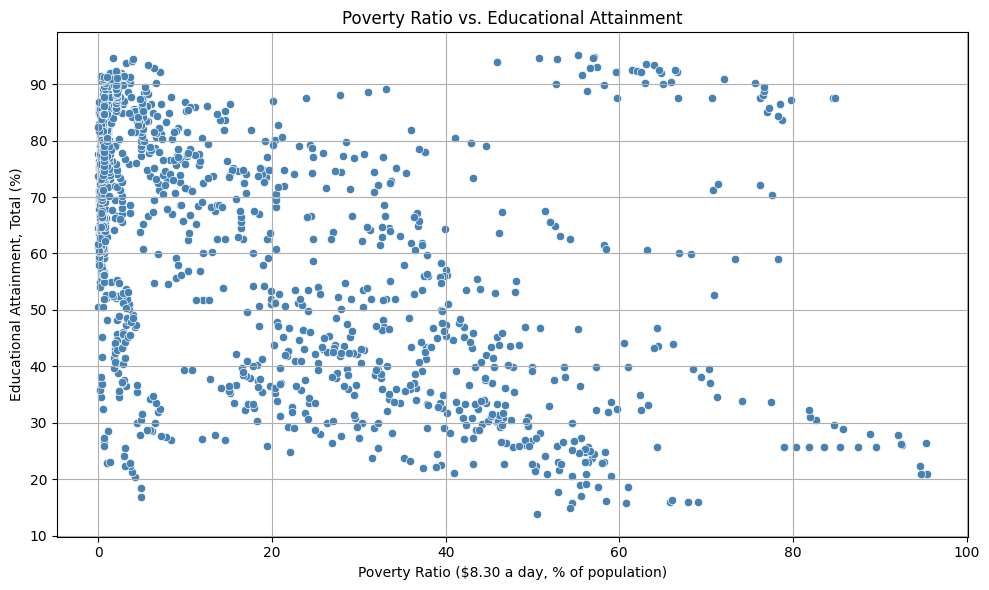

In [ ]:
# plot of original poverty and educational attainment
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_wide['Poverty_Ratio_Wage'], y=df_wide['Educational_Attainment_Total'], color='steelblue')
plt.title('Poverty Ratio vs. Educational Attainment')
plt.xlabel('Poverty Ratio ($8.30 a day, % of population)')
plt.ylabel('Educational Attainment, Total (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

#roughly negatively correlated with poverty, as expected

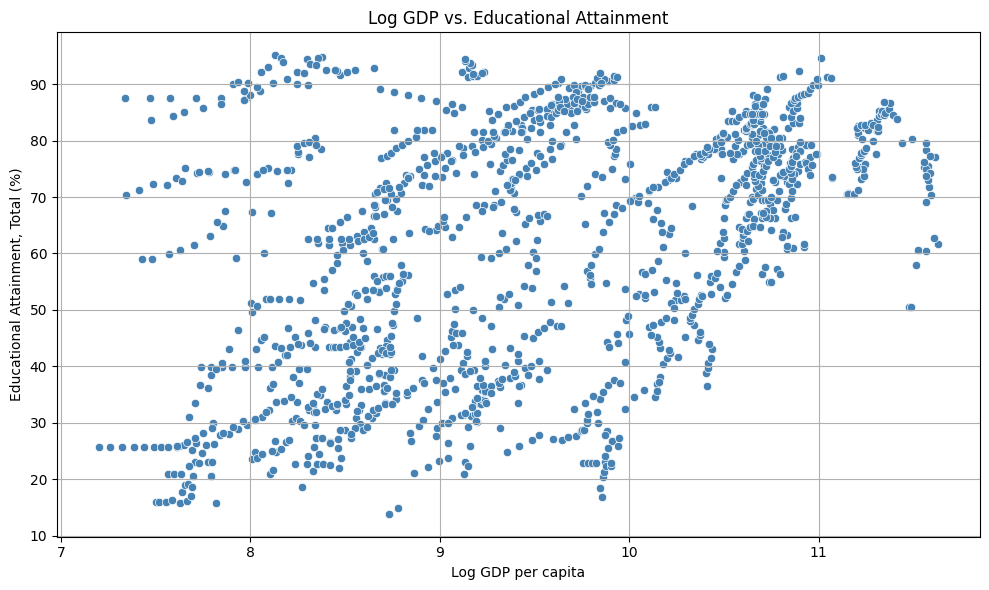

In [ ]:
# plot of log GDP per capita and educational attainment
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_wide['log_GDP_Constant'], y=df_wide['Educational_Attainment_Total'], color='steelblue')
plt.title('Log GDP vs. Educational Attainment')
plt.xlabel('Log GDP per capita')
plt.ylabel('Educational Attainment, Total (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

#roughly positively correlated with gdp per capita, as expected
#but I'm not sure if its an issue to use predictor variables that have the opposite correlations with the dependant variable


##Regression


In [ ]:
# create ordinary least squares model
model = smf.ols('Educational_Attainment_Total ~ Poverty_Ratio_Wage + log_GDP_Constant', data=df_wide)

# fit model
results = model.fit()

# print results
print(results.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Educational_Attainment_Total   R-squared:                       0.234
Model:                                      OLS   Adj. R-squared:                  0.233
Method:                           Least Squares   F-statistic:                     201.7
Date:                          Fri, 10 Apr 2026   Prob (F-statistic):           3.59e-77
Time:                                  16:58:48   Log-Likelihood:                -5761.2
No. Observations:                          1323   AIC:                         1.153e+04
Df Residuals:                              1320   BIC:                         1.154e+04
Df Model:                                     2                                         
Covariance Type:                      nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

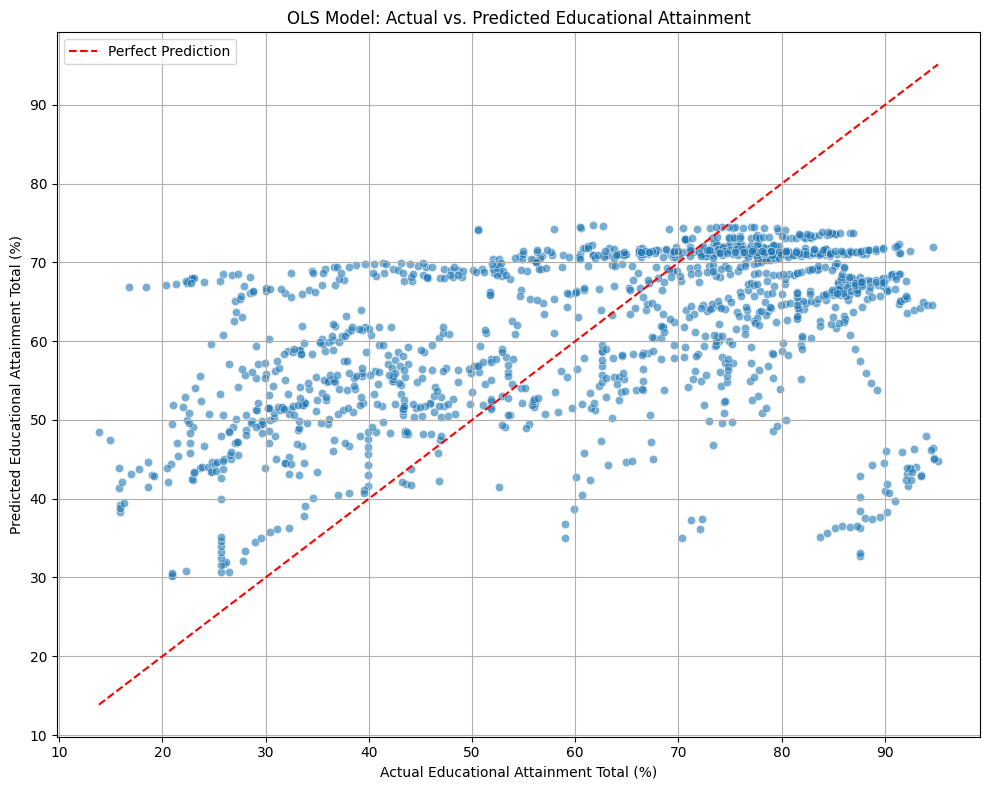

In [ ]:
# Get actual values (dependent variable)
actual_values = df_wide['Educational_Attainment_Total']

# Get predicted values from the OLS model
predicted_values = results.predict(df_wide[['Poverty_Ratio_Wage', 'log_GDP_Constant']])

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Actual': actual_values,
    'Predicted': predicted_values
})

# Plot actual vs. predicted values
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Actual', y='Predicted', data=plot_df, alpha=0.6)

# Add a line for perfect prediction
plt.plot([plot_df['Actual'].min(), plot_df['Actual'].max()],
         [plot_df['Actual'].min(), plot_df['Actual'].max()],
         color='red', linestyle='--', label='Perfect Prediction')

plt.title('OLS Model: Actual vs. Predicted Educational Attainment')
plt.xlabel('Actual Educational Attainment Total (%)')
plt.ylabel('Predicted Educational Attainment Total (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Creating new model with 80/20 train/test split to make predictions
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Create an 80/20 train/test split
from sklearn.model_selection import train_test_split

X = df_wide[['Poverty_Ratio_Wage', 'log_GDP_Constant']]
Y = df_wide['Educational_Attainment_Total']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
lin_reg_model = LinearRegression()

# Train the model using the training data
lin_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lin_reg = lin_reg_model.predict(X_test)

# Calculate the R-squared score
r_squared_lin_reg = r2_score(y_test, y_pred_lin_reg)

print(f"Linear Regression R-squared on test set: {r_squared_lin_reg:.3f}")

Linear Regression R-squared on test set: 0.267


In [ ]:
from sklearn.metrics import mean_squared_error

mse_lin_reg = mean_squared_error(y_test, y_pred_lin_reg)

print(f"Linear Regression Mean Squared Error on test set: {mse_lin_reg:.3f}")

Linear Regression Mean Squared Error on test set: 330.018


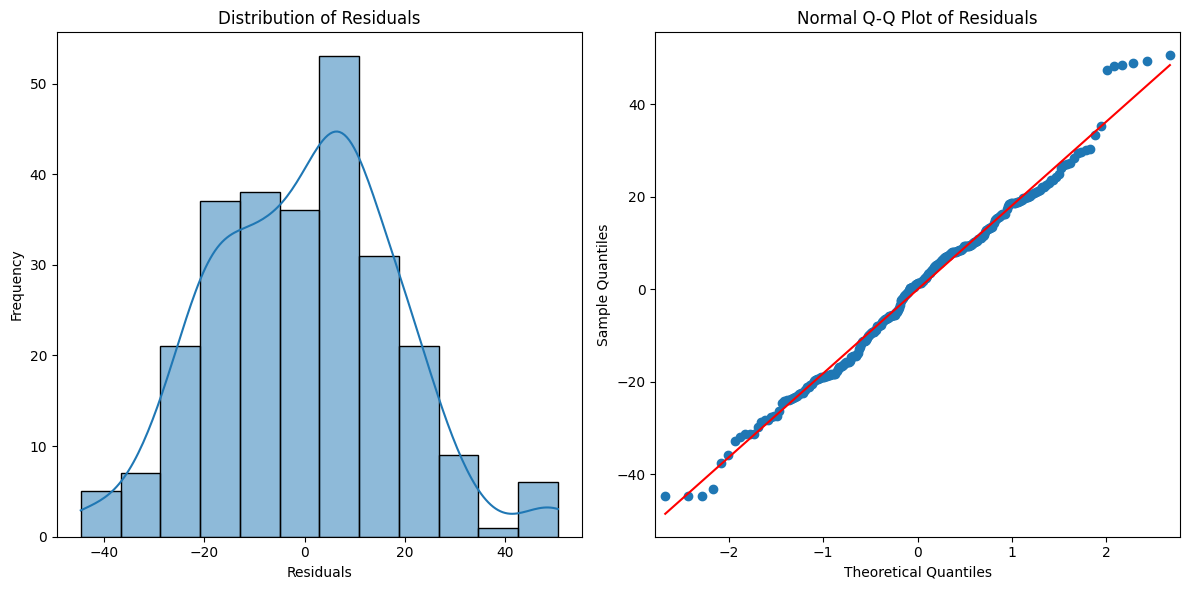

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Calculate residuals
residuals = y_test - y_pred_lin_reg

# Plotting the distribution of residuals
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # Histogram of residuals
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # Q-Q plot
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Normal Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

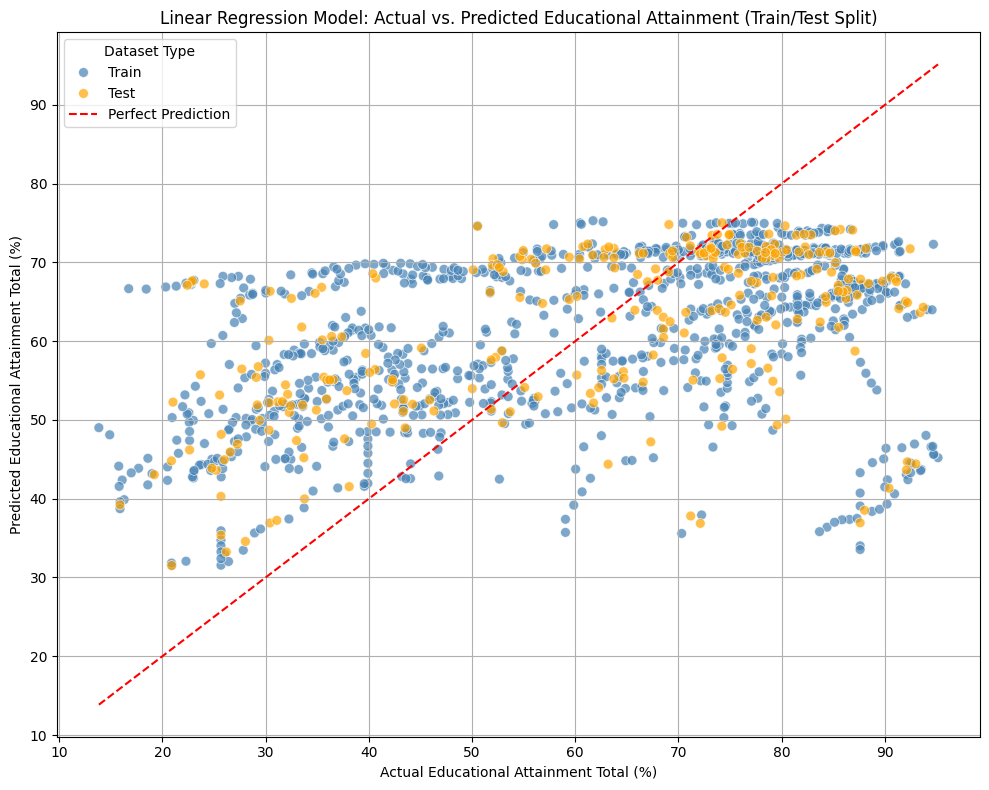

In [ ]:
# Make predictions on the training set
y_pred_lin_reg_train = lin_reg_model.predict(X_train)

# Create DataFrames for plotting actual vs. predicted for train and test sets
plot_train_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_pred_lin_reg_train,
    'Dataset_Type': 'Train'
})

plot_test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_lin_reg,
    'Dataset_Type': 'Test'
})

# Concatenate train and test DataFrames
full_plot_df = pd.concat([plot_train_df, plot_test_df])

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Actual',
    y='Predicted',
    hue='Dataset_Type',
    palette={'Train': 'steelblue', 'Test': 'orange'},
    alpha=0.7,
    s=50,
    data=full_plot_df
)

# Add a line for perfect prediction
min_val = full_plot_df[['Actual', 'Predicted']].min().min()
max_val = full_plot_df[['Actual', 'Predicted']].max().max()
plt.plot([min_val, max_val],
         [min_val, max_val],
         color='red', linestyle='--', label='Perfect Prediction')

plt.title('Linear Regression Model: Actual vs. Predicted Educational Attainment (Train/Test Split)')
plt.xlabel('Actual Educational Attainment Total (%)')
plt.ylabel('Predicted Educational Attainment Total (%)')
plt.legend(title='Dataset Type')
plt.grid(True)
plt.tight_layout()
plt.show()

# Creating models using other x and y variables to compare to the one above

In [ ]:
# create ordinary least squares model
model2 = smf.ols('Educational_Attainment_Male ~ Poverty_Ratio_Wage + log_GDP_Constant', data=df_wide)

# fit model
results = model2.fit()

# print results
print(results.summary())

# same predictors explain less of the variance of Male/Female educational attainment than compared to total ed attainment

                                 OLS Regression Results                                
Dep. Variable:     Educational_Attainment_Male   R-squared:                       0.232
Model:                                     OLS   Adj. R-squared:                  0.231
Method:                          Least Squares   F-statistic:                     199.4
Date:                         Fri, 10 Apr 2026   Prob (F-statistic):           2.14e-76
Time:                                 16:58:49   Log-Likelihood:                -5795.6
No. Observations:                         1323   AIC:                         1.160e+04
Df Residuals:                             1320   BIC:                         1.161e+04
Df Model:                                    2                                         
Covariance Type:                     nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

In [ ]:
# create ordinary least squares model
model3 = smf.ols('Educational_Attainment_Total ~ Poverty_Ratio_National + log_GDP_Constant', data=df_wide)

# fit model
results = model3.fit()

# print results
print(results.summary())

# poverty ratio national explains less variance than poverty ratio wage

                                 OLS Regression Results                                 
Dep. Variable:     Educational_Attainment_Total   R-squared:                       0.207
Model:                                      OLS   Adj. R-squared:                  0.206
Method:                           Least Squares   F-statistic:                     156.2
Date:                          Fri, 10 Apr 2026   Prob (F-statistic):           5.48e-61
Time:                                  16:58:49   Log-Likelihood:                -5236.6
No. Observations:                          1197   AIC:                         1.048e+04
Df Residuals:                              1194   BIC:                         1.049e+04
Df Model:                                     2                                         
Covariance Type:                      nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [ ]:
# create ordinary least squares model
model4 = smf.ols('Educational_Attainment_Male ~ Poverty_Ratio_National + log_GDP_Constant', data=df_wide)

# fit model
results = model4.fit()

# print results
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:     Educational_Attainment_Male   R-squared:                       0.217
Model:                                     OLS   Adj. R-squared:                  0.215
Method:                          Least Squares   F-statistic:                     165.1
Date:                         Fri, 10 Apr 2026   Prob (F-statistic):           5.10e-64
Time:                                 16:58:49   Log-Likelihood:                -5260.4
No. Observations:                         1197   AIC:                         1.053e+04
Df Residuals:                             1194   BIC:                         1.054e+04
Df Model:                                    2                                         
Covariance Type:                     nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [ ]:
# Model with fixed effects (just trying this - Addie); control for differences within countries
# Now instead of countries with higher poverty have lower education,
#      it's when poverty increases within a country, does education tend to decrease?
#      Does reducing poverty within a country improve education

# fixed effects ordinary least squares model
model_ols = smf.ols('Educational_Attainment_Total ~ Poverty_Ratio_Wage + log_GDP_Constant', data=df_wide)

# fit model
results_ols = model_ols.fit()

# fixed effects ordinary least squares model
model_fixed = smf.ols('Educational_Attainment_Total ~ Poverty_Ratio_Wage + log_GDP_Constant + C(Country) + C(Year)', data=df_wide)

# fit model
results_fixed = model_fixed.fit()

# print results
print(results_fixed.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Educational_Attainment_Total   R-squared:                       0.977
Model:                                      OLS   Adj. R-squared:                  0.976
Method:                           Least Squares   F-statistic:                     627.6
Date:                          Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                                  16:58:49   Log-Likelihood:                -3440.7
No. Observations:                          1323   AIC:                             7051.
Df Residuals:                              1238   BIC:                             7492.
Df Model:                                    84                                         
Covariance Type:                      nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
---

In [ ]:
comparison = pd.DataFrame({
    'OLS_coef': results_ols.params,
    'Fixed_coef': results_fixed.params,
    'OLS_pval': results_ols.pvalues,
    'Fixed_pval': results_fixed.pvalues
})

# only keep main variables
comparison.loc[['Poverty_Ratio_Wage', 'log_GDP_Constant']]

,OLS_coef,Fixed_coef,OLS_pval,Fixed_pval
Poverty_Ratio_Wage,-0.316522,-0.027987,4.671489e-14,0.124718
log_GDP_Constant,3.548251,0.744974,5.988764e-05,0.537403


When doing the original ordinary least squares on predicting educational attainment from poverty and GDP, it looks at the data both between countries (comparing US to India) and within countries (US in 2003 vs 2013). So it does more correlation, like "countries with higher poverty tend to have lower educational attainment levels". But if we wanted to look at within a country, how educational attainment can change as poverty and GDP change within, then we can control for "country" and "year". After doing this, poverty and GDP are not very significant predictors.

In [ ]:
from sklearn.preprocessing import StandardScaler

#Standardize the data
scaler = StandardScaler()
df_wide_scaled = df_wide.copy()
df_wide_scaled['Poverty_Ratio_Wage_std'] = scaler.fit_transform(df_wide[['Poverty_Ratio_Wage']])
df_wide_scaled['log_GDP_Constant_std'] = scaler.fit_transform(df_wide[['log_GDP_Constant']])

# create ordinary least squares model with interaction term
model5 = smf.ols('Educational_Attainment_Total ~ Poverty_Ratio_Wage + log_GDP_Constant + Poverty_Ratio_Wage:log_GDP_Constant', data=df_wide_scaled)

# fit model
results = model5.fit()

# print results
print(results.summary())
# doesn't greately improve model and creates multicollinearity issues

                                 OLS Regression Results                                 
Dep. Variable:     Educational_Attainment_Total   R-squared:                       0.263
Model:                                      OLS   Adj. R-squared:                  0.262
Method:                           Least Squares   F-statistic:                     157.1
Date:                          Fri, 10 Apr 2026   Prob (F-statistic):           4.67e-87
Time:                                  16:58:49   Log-Likelihood:                -5735.6
No. Observations:                          1323   AIC:                         1.148e+04
Df Residuals:                              1319   BIC:                         1.150e+04
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

#set columns for x and y and standardize x
X = df_wide[['Poverty_Ratio_Wage', 'log_GDP_Constant']]
scaler = scaler.fit_transform(X)
y = df_wide['Educational_Attainment_Total']

# try ridge regularization with different alpha values
for alpha in [0.1, 1.0, 10.0, 100.0]:
  ridge = Ridge(alpha=alpha)
  cv_scores = cross_val_score(ridge, X, y)
  print(f"Alpha={alpha}: Mean CV R² = {cv_scores.mean():.3f}")
# boo regularization makes it worse - underfitting

Alpha=0.1: Mean CV R² = 0.129
Alpha=1.0: Mean CV R² = 0.130
Alpha=10.0: Mean CV R² = 0.132
Alpha=100.0: Mean CV R² = 0.146


In [ ]:
# trying one more thing - create log target
y_log = np.log(df_wide['Educational_Attainment_Total'])

#Fit OLS
model6 = smf.ols('y_log ~ Poverty_Ratio_Wage + log_GDP_Constant', data=df_wide)
results = model6.fit()
print(results.summary())
#slightly better R2 but worsened other measures (residuals not normally distributed) - original regression seems better

                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     233.3
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.80e-87
Time:                        16:58:49   Log-Likelihood:                -541.74
No. Observations:                1323   AIC:                             1089.
Df Residuals:                    1320   BIC:                             1105.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              3.5929      0

In [ ]:
# Filter to 2016 only
df_2016 = df_wide[df_wide['Year'] == 2016]

# ols with just 2016 data
model7 = smf.ols('Educational_Attainment_Total ~ Poverty_Ratio_Wage + log_GDP_Constant', data=df_2016)

# fit model
results = model7.fit()

# print results
print(results.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Educational_Attainment_Total   R-squared:                       0.209
Model:                                      OLS   Adj. R-squared:                  0.183
Method:                           Least Squares   F-statistic:                     7.927
Date:                          Fri, 10 Apr 2026   Prob (F-statistic):           0.000881
Time:                                  16:58:49   Log-Likelihood:                -271.63
No. Observations:                            63   AIC:                             549.3
Df Residuals:                                60   BIC:                             555.7
Df Model:                                     2                                         
Covariance Type:                      nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

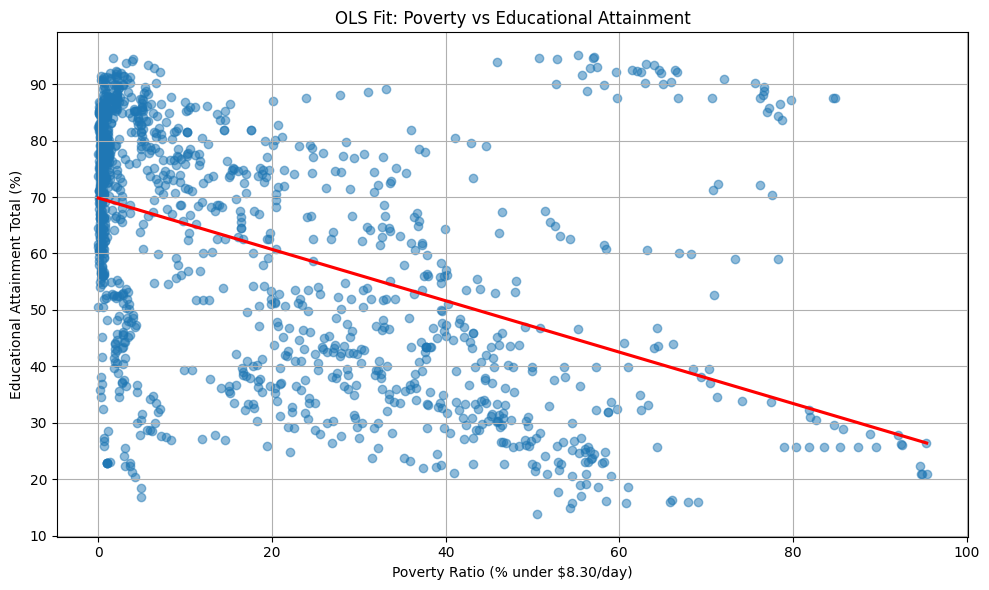

In [ ]:
# See line of best for for OLS poverty vs education
plt.figure(figsize=(10, 6))

sns.regplot(
    x='Poverty_Ratio_Wage',
    y='Educational_Attainment_Total',
    data=df_wide,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'},
    ci=None
)

plt.title('OLS Fit: Poverty vs Educational Attainment')
plt.xlabel('Poverty Ratio (% under $8.30/day)')
plt.ylabel('Educational Attainment Total (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

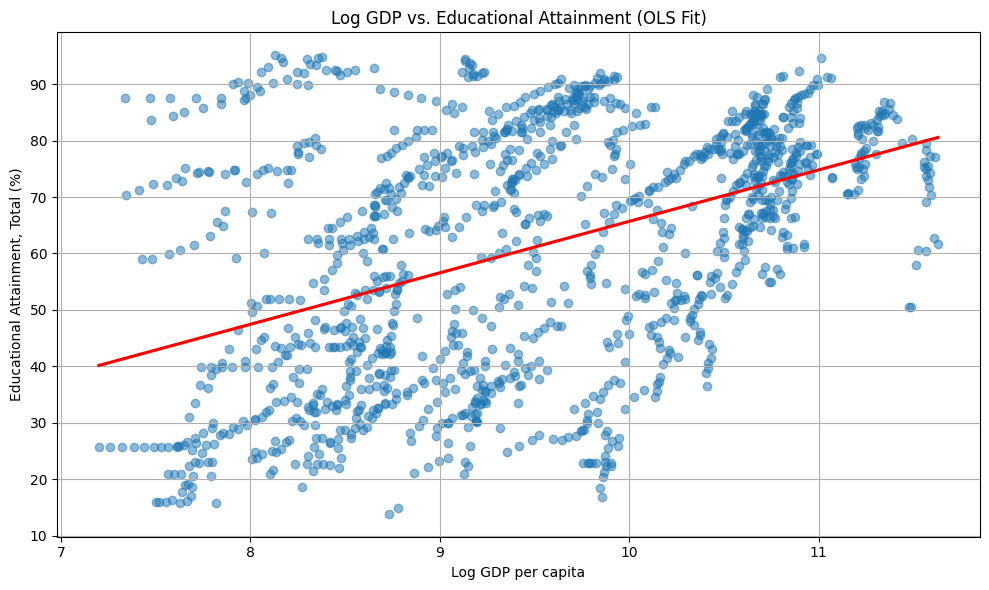

In [ ]:
# Look at line of best fit for log GDP
plt.figure(figsize=(10, 6))

sns.regplot(
    x='log_GDP_Constant',
    y='Educational_Attainment_Total',
    data=df_wide,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'},
    ci=None
)

plt.title('Log GDP vs. Educational Attainment (OLS Fit)')
plt.xlabel('Log GDP per capita')
plt.ylabel('Educational Attainment, Total (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# would random forest help?
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GroupKFold

In [ ]:
X = df_wide[['Poverty_Ratio_National', 'Poverty_Ratio_Wage', 'log_GDP_Constant']]
Y = df_wide['Educational_Attainment_Total']

# train/test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2,random_state=42)


In [ ]:

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth= 5,
    min_samples_split= 20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print("R²: ", round(r2_score(y_test, preds), 3))
print("MSE:", round(mean_squared_error(y_test, preds), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, preds)), 3))

R²:  0.635
MSE: 164.353
RMSE: 12.82


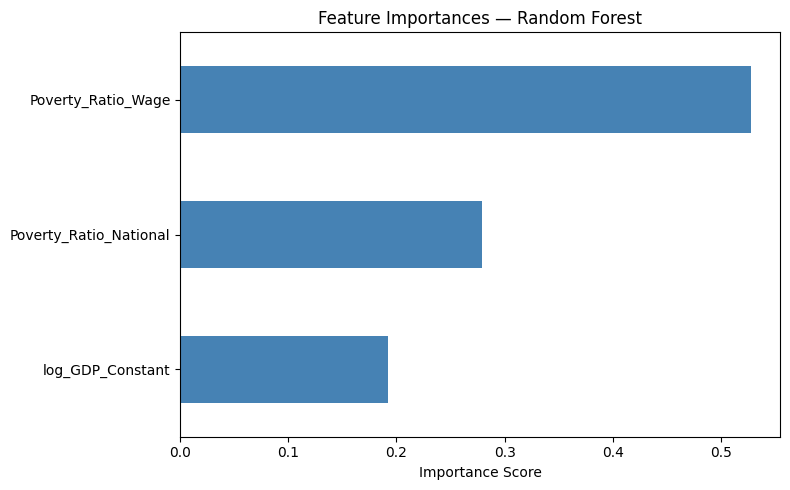

In [ ]:
# plotting
importances = pd.Series(rf.feature_importances_, index=['Poverty_Ratio_National', 'Poverty_Ratio_Wage', 'log_GDP_Constant'])
importances.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# cross validate the model
groups = df_wide['Country']
gkf = GroupKFold(n_splits=5)

cv_scores = cross_val_score(rf, X, Y, cv=gkf, groups=groups, scoring='r2')
print("\n── Group Cross-Validation ──")
print("CV R² scores:", cv_scores.round(3))
print("Mean R²:     ", round(cv_scores.mean(), 3))
print("Std:         ", round(cv_scores.std(), 3))


── Group Cross-Validation ──
CV R² scores: [-0.164 -0.302  0.141  0.24  -0.365]
Mean R²:      -0.09
Std:          0.24


In [ ]:
#trying another tree-based model with more regularization
from xgboost import XGBRegressor

X = df_wide[['Poverty_Ratio_National', 'Poverty_Ratio_Wage', 'log_GDP_Constant']]
Y = df_wide['Educational_Attainment_Total']

#scale x
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#try xgboost with varying regularization
for reg_lambda in [0.1, 1.0, 10.0, 100.0, 500.00]:
  xgb = XGBRegressor(
      n_estimators=100,
      max_depth=3, #keep shallow
      learning_rate=0.1,
      reg_lambda=reg_lambda,
      random_state=42
  )

  cv_scores = cross_val_score(xgb, X_scaled, y)
  print(f"Lambda={reg_lambda}: Mean CV R² = {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
  #still not as good as original ols!


Lambda=0.1: Mean CV R² = 0.099 (+/- 0.149)
Lambda=1.0: Mean CV R² = 0.138 (+/- 0.158)
Lambda=10.0: Mean CV R² = 0.149 (+/- 0.147)
Lambda=100.0: Mean CV R² = 0.182 (+/- 0.123)
Lambda=500.0: Mean CV R² = 0.185 (+/- 0.111)
